In [ ]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: ignored

In [ ]:
%cd /content/drive/My\ Drive

/content/drive/My Drive


In [ ]:
import tensorflow as tf
import tensorflow as ktf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense, Conv2D, Flatten,GlobalMaxPooling2D, Dropout, MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,concatenate,Input,Lambda
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from collections import Counter
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import json
import glob
import itertools
import itertools
import glob
from sklearn.metrics import confusion_matrix
import tensorflow as ktf

In [ ]:
# the implemented model

# TODO: build the VGG16-based transfer learning model — resize
# input images to 224x224, load VGG16 (imagenet weights, no top),
# add Flatten -> Dense(1024, relu) -> BatchNorm -> Dense(1, sigmoid),
# and wrap it all in a Model(inputs=vgg_input, outputs=vgg_output).
vgg = None

In [ ]:
from tensorflow.keras import optimizers

base_learning_rate = 0.001

vgg.compile(optimizer='adadelta',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
from tensorflow.keras.preprocessing import image
train_datagen = image.ImageDataGenerator(
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
validation_datagen= image.ImageDataGenerator(    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1)
test_datagen= image.ImageDataGenerator(    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/oral/train/',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'binary')
validation_generator = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/oral/val/',
    target_size = (224,224),
    batch_size = 8,
    shuffle=True,
    class_mode = 'binary')
test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/oral/test/',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'binary')

Found 3645 images belonging to 2 classes.
Found 1046 images belonging to 2 classes.
Found 517 images belonging to 2 classes.


In [ ]:
labels = train_generator.class_indices

In [ ]:
print(train_generator.class_indices)
print(validation_generator.class_indices)
print(test_generator.class_indices)

{'Normal': 0, 'OSCC': 1}
{'Normal': 0, 'OSCC': 1}
{'Normal': 0, 'OSCC': 1}


In [ ]:
labels

{'Normal': 0, 'OSCC': 1}

In [ ]:
def plot_learning_curve(history):
    plt.figure(figsize=(16, 8))
    plt.subplot(1,3,1)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch No.')
    acc = "Train Accuracy:{}".format(str(round(history['accuracy'][-1],2)))
    val_acc = "Val Accuracy:{}".format(str(round(history['val_accuracy'][-1],2)))
    plt.legend([acc, val_acc], loc='upper left')
    plt.savefig('/content/drive/My Drive/Accuracy_Curve1.png')
    #plt.clf()
    # summarize history for loss
    plt.subplot(1,3,2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch No.')
    loss = "Train Loss:{}".format(str(round(history['loss'][-1],2)))
    val_loss = "Val Loss:{}".format(str(round(history['val_loss'][-1],2)))
    plt.legend([loss, val_loss], loc='upper right')
    plt.savefig('/content/drive/My Drive/Loss_Curve1.png')

In [ ]:
#Early stopping is to prevent the overfitting

es = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', verbose=1, patience=15)

# ModelCheckpoint is used  to save the best weights based on the monitor metric

checkpoint = tf.keras.callbacks.ModelCheckpoint('vgg.h5', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

In [ ]:
import pickle,json

model_info = vgg.fit(train_generator,
                    epochs=80,
                    validation_data=validation_generator)

vgg.save_weights('vgg_weights.h5')

history_dict = model_info.history

json.dump(history_dict, open('/content/drive/My Drive/covid_train.json', 'w'))

plot_learning_curve(history_dict)

vgg.evaluate(test_generator)

Epoch 1/80
114/456 [======>.......................] - ETA: 1:58:32 - loss: 0.8697 - accuracy: 0.5154

In [ ]:
vgg.save("oral.h5")

In [ ]:
loaded_model = tf.keras.models.load_model('oral.h5')

loaded_model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

loaded_model.evaluate(testing_set)

17/17 [==============================] - 70s 4s/step - loss: 0.3916 - accuracy: 0.8665


[0.39156216382980347, 0.8665376901626587]

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion_matrix of covid.png',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    # TODO: optionally normalize cm, compute sensitivity/specificity
    # from the confusion matrix, convert cell counts to percentages,
    # then plot the matrix with matplotlib (imshow, colorbar, axis
    # ticks/labels, per-cell text annotations) and save it to a file.
    pass

In [ ]:
model=load_model('/content/drive/My Drive/oral.h5')
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 lambda (Lambda)             (None, 224, 224, 3)       0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 1024)              25691136  
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                             

In [ ]:
# TODO: for each saved model checkpoint (here just oral.h5), load it,
# run predictions over the test set one image at a time, compare
# each prediction to the true label, and tally true/false counts,
# writing a summary line per model to incresnt_metrics2.txt.
pass

In [ ]:
# TODO: define a function that loads Normal and OSCC test images from
# disk, runs the model on each, collects true labels vs predictions,
# then prints a confusion matrix, accuracy, F1, recall, and precision.
dataset = np.ndarray(shape=(1, 224, 224, 3),dtype=np.float32)

def covid_test(model):
    pass

Streaming output truncated to the last 5000 lines.
1/1 [==============================] - 0s 19ms/step
Counter({1: 2698, 0: 2504})
Counter({0: 2693, 1: 2509})
Confusion matrix, without normalization
[[2292  212]
 [ 401 2297]]
the sensitivity 0.8510954326030449
the specificity 0.9155041849342368
92 8 15 85
[[92  8]
 [15 85]]
0.882160707420223
0.8821648225320419
0.882160707420223
0.8845008177990379


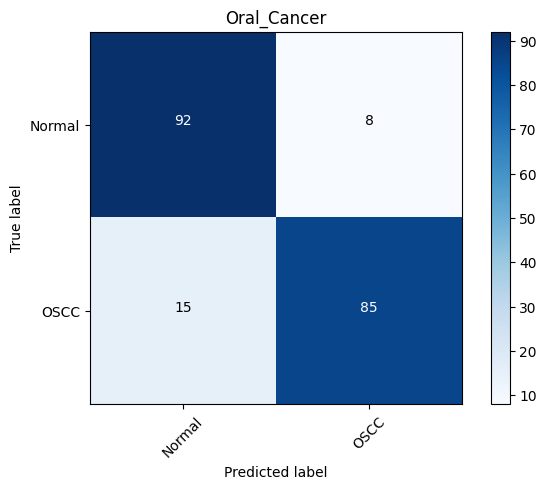

In [ ]:
covid_test(loaded_model)